<a href="https://www.kaggle.com/code/jatin2055/langgraph-iterative-workflow?scriptVersionId=265504648" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [34]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [35]:
# pip install langgraph
# pip install langchain
# pip install langchain_openai
# pip install langchain_core

In [36]:
from langgraph.graph import START, END, StateGraph
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

from typing import TypedDict, Literal, Annotated
from typing_extensions import NotRequired
from pydantic import BaseModel, Field
from langsmith import traceable

# 1. LLMS

In [37]:
api_key='your_api_key'

langsmith = 'your_api_key'

os.environ["LANGCHAIN_API_KEY"] = langsmith
os.environ["LANGCHAIN_TRACING_V2"]="true"
os.environ["LANGCHAIN_PROJECT"]="LangGraph - Iterative"

os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'

In [38]:
# generator llm

generator_llm = ChatOpenAI(model='gpt-4o', api_key=api_key)

# evaluator llm
evaluator_llm = ChatOpenAI(model='gpt-4o-mini', api_key=api_key)

# optimizer llm
optimizer_llm = ChatOpenAI(model='gpt-4o', api_key=api_key)


# 2. Defining State schema

# EvaluationMetrics

In [39]:
class EvaluationMetrics(BaseModel):

    """
        Structured metrics used to evaluate the technical article content.
    """
    technical_depth: int = Field(
        description="Score (1-5, 5=Excellent) for in-depth analysis and technical accuracy.",
        ge=1, le=5
    )
    language_clarity: int = Field(
        description="Score (1-5, 5=Excellent) for grammar, professional tone, and clarity.",
        ge=1, le=5
    )
    subheading_structure: int = Field(
        description="Score (1-5, 5=Excellent) for organization, logical flow, and effective use of sub-headings.",
        ge=1, le=5
    )
    conciseness: int = Field(
        description="Score (1-5, 5=Excellent) for being direct and avoiding unnecessary filler content.",
        ge=1, le=5
    )
    topic_focus: int = Field(
        description="Score (1-5, 5=Excellent) for strict adherence to the provided topic.",
        ge=1, le=5
    )
    subheading_count_met: bool = Field(
        description="True if 5 or more distinct, relevant sub-headings were found in the article."
    )

# EvaluationSchema

In [40]:
class EvaluationSchema(BaseModel):

    evaluation: Literal["approved", "needs_improvement"]= Field(..., description="Final evaluation result.") # ... means field is mandatory attribute
    feedback: str = Field(..., description="Provide feedback based on the article's evaluation.")
    evaluationMetrics: EvaluationMetrics

# TweetState

In [41]:
# generating tweet
# state
class TweetState(TypedDict):

    topic: Annotated[str, 'Topic from the user']
    generate_tweet: Annotated[str, 'Tweet generated based on the topic']
    #evaluation: Annotated[Literal["approved", "needs_improvement"], 'Evaluation result']
    #feedback: Annotated[str, "feedback shared by the evaluator"]
    iteration: Annotated[int, "no of iterations performed"]
    max_iter: Annotated[int, "max no of iterations permitted"]
    final_tweet: Annotated[str, "final tweet after approval from evaulator"]
    article_evaluation: Annotated[NotRequired[EvaluationSchema], "Structured evaluation feedback."]
    
    
    


In [42]:
structured_evaluator_llm = evaluator_llm.with_structured_output(EvaluationSchema)

# 3. Node Functions

# generate_tweet

In [43]:
@traceable(name="generate_tweet", tags=["dimension:language"], metadata={"dimension": "language"})
def generate_tweet(state: TweetState):
    print('*#-'*60)
    # prompt
    messages_memory = [
        
        SystemMessage(
            content=f"""You are smart and intellegent Article Writer. You write articles explaining about 
            emerging AI & ML based topics in in-depth and easy language."""
        ),
        HumanMessage(f"""
            Write an article on the topic: {state['topic']}.
    
            Rules:
            1. It should be atleast 200 words
            2. It should contain atleast 5 headers with Introduction and Summary
            3. Use easy and casual language
            4. Prefere flow diagram
            5. Include small case study or real world examples to explain
            6. This is version {state['iteration'] + 1} of the article
        """)
    ] 

    

    # send for tweet generation to llm
    response = generator_llm.invoke(messages_memory).content
    print('-'*10)
    print(f"generate_tweet: {response}")
    # return response
    return {'generate_tweet': response, 'final_tweet': response}

# evaluate_tweet

In [44]:
@traceable(name="evaluate_tweet", tags=["evaluate_tweet"], metadata={"dimension": "language"})
def evaluate_tweet(state: TweetState):
    print('*#-'*60)
    # prompt
    systemPrompt = f"""
        You are a world-class, objective Technical Content Evaluator and Editor. Your sole function is to rigorously review the provided technical article against five strict quality metrics.
        
        STRICT INSTRUCTIONS & METRICS:
        1.  In-Depth Analysis/Technical Accuracy (Score 1-5): Evaluate the depth of explanation, correctness of technical concepts, use of specific examples, and evidence of specialized knowledge.
        2.  Language Used & Clarity (Score 1-5): Evaluate grammar, syntax, professional tone, clarity of complex ideas, and overall readability.
        3.  Sub-heading Structure (Score 1-5 & Count): Evaluate logical flow and organization. Crucially, verify that the article includes a minimum of 5 distinct, relevant sub-headings (excluding the main title, introduction, and conclusion).
        4.  Conciseness / To the Point (Score 1-5): Evaluate the efficiency of the writing. The article must avoid filler, unnecessary jargon, and lengthy tangents.
        5.  Topic Relevance / Focus (Score 1-5): The content must strictly adhere to the provided topic and prompt requirements, avoiding unrelated material.
        
        OUTPUT RULES (Non-Negotiable):
        * Response: You MUST respond only with a single JSON object that strictly adheres to the provided JSON Schema.
        * Status Determination:
            * Set \`status\` to "APPROVED" only if ALL five metrics (1-5) score 4 or higher, AND the \`subheading_count_met\` field is \`true\`.
            * Otherwise, set \`status\` to "NEEDS_IMPROVEMENT"
        * Feedback Field: The \`feedback\` field must contain a detailed, professional, and constructive paragraph summarizing the article's performance against all five core metrics, explaining the final status decision.
    """

    userQuery = f"""
        Please evaluate the following technical article based on the instructions provided in your system prompt.
        Article: {state['final_tweet']}
        Analyze the content and return ONLY the JSON object defined in the schema.
    """

    messages = [
        SystemMessage(
            content = systemPrompt
        ),
        HumanMessage(
            content = userQuery
        )
    ]
    print('-'*10)
    print(f"evaluate_tweet_state: {state}")
    
    # send for evaluation 
    response = structured_evaluator_llm.invoke(messages)

    print('-'*10)
    print(f"evaluate_tweet_response: {response}")
    print('-'*10)
    print(f"evaluate_tweet_response: {response.model_dump()}")
    # response
    return {
        'article_evaluation': response.model_dump()
    }
    # return {
    #     'article_evaluation': response.evaluation,
    #     'feedback': response.feedback,
    #     'evaluationMetrics': response.evaluationMetrics
    # }




# optimize_tweet

In [45]:
@traceable(name="optimize_tweet", tags=["optimize_tweet"], metadata={"dimension": "language"})
def optimize_tweet(state: TweetState):

    print('*#-'*60)

    systemPrompt = f"""
        You are a highly skilled Technical Content Editor and Optimizer. Your primary goal is to take a draft article, a target topic, and structured evaluation feedback, and generate a new, fully optimized version of the article.
        
        INSTRUCTIONS FOR OPTIMIZATION:
        
        1.  Analyze the Feedback: You MUST analyze the \`evaluationMetrics\` (especially any score below 4) and the narrative \`feedback\` provided .
        2.  Target Improvements:
            * If Technical Depth is low: Add more complex examples, ensure technical concepts are rigorously explained, and use more domain-specific evidence.
            * If Language Clarity is low: Rewrite sentences for better flow, correct all grammatical errors, and ensure the tone is consistently professional and authoritative.
            * If Sub-heading Structure is low or count is not met: Rework the article's organization, ensure there are at least 5 distinct, relevant sub-headings, and improve the logical transition between sections.
            * If Conciseness is low: Ruthlessly eliminate filler words, unnecessary introductory phrases, and any tangents to make the content direct and impactful.
            * If Topic Focus is low: Remove any material that deviates from the provided \`ARTICLE TOPIC\` and reinforce adherence to the central theme.
        3.  Final Output: Your response MUST be the complete, optimized article content in clean Markdown format, ready for publication. DO include any commentary, introductions, or surrounding text outside of the article itself.
        """

    userQuery = f"""
        Please act as the Technical Editor and optimize the following article based on the provided feedback 

        Article: {state['final_tweet']}

        EVALUATION FEEDBACK: {state['article_evaluation']}

    """

    messages = [
        SystemMessage(content= systemPrompt),
        HumanMessage(content= userQuery)
        
    ]
    print('-'*10)
    print(f"optimize_tweet_state: {state}")
    
    response = optimizer_llm.invoke(messages).content

    state['generate_tweet'] = state['final_tweet']

    print('-'*10)
    print(f"optimize_tweet_response: {response}")
    print('-'*10)
    print(f"optimize_tweet_state: {state}")

    return {
        'final_tweet': response,
        'iteration': state['iteration'] + 1
    }

# {
#           "status": "NEEDS_IMPROVEMENT",
#           "feedback": "The article's main weakness is the lack of technical depth (score 2) and poor organization (score 2) with only three functional sub-headings, failing the required minimum count. Language is decent but often verbose, hindering conciseness (score 3).",
#           "evaluationMetrics": {
#             "technical_depth": 2,
#             "language_clarity": 4,
#             "subheading_structure": 2,
#             "conciseness": 3,
#             "topic_focus": 5,
#             "subheading_count_met": false
#           }


    
    

# route_evaluation

In [46]:
@traceable(name="route_evaluation", tags=["route"], metadata={"dimension": "language"})
def route_evaluation(state: TweetState):
    print('*#-'*60)
    
    print('-'*10)
    print(f"route_evaluation - state: {state}")
    
    if state['article_evaluation']['evaluation'] == 'approved' or state['iteration']>state['max_iter']:
        return 'approved'
    else:
        return 'needs_improvement'
        

# 4. State Graph

In [47]:
graph = StateGraph(TweetState)

graph.add_node('generate_tweet', generate_tweet)
graph.add_node('evaluate_tweet', evaluate_tweet)
graph.add_node('optimize_tweet', optimize_tweet)

graph.add_edge(START, 'generate_tweet')
graph.add_edge('generate_tweet', 'evaluate_tweet')

graph.add_conditional_edges('evaluate_tweet', route_evaluation, {'approved': END, 'needs_improvement': 'optimize_tweet'})

graph.add_edge('optimize_tweet', 'evaluate_tweet')

checkpointer = InMemorySaver() # to save the checkpointers and thereby state in the Memory

workflow = graph.compile(checkpointer=checkpointer)


# 5. WorkFlow Diagram

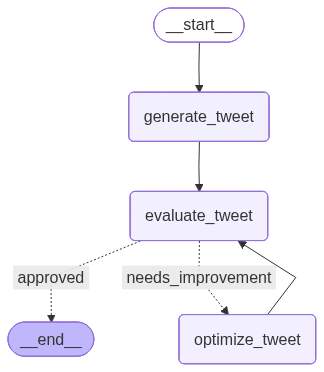

In [48]:
workflow

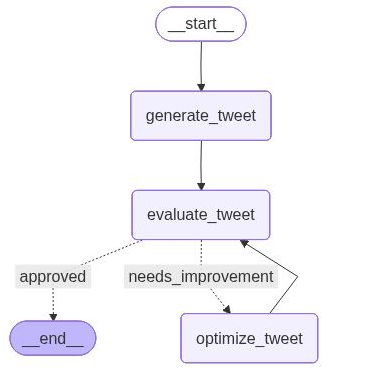

In [49]:
topic = "Agentic AI"

config = {"configurable": {
    "thread_id": "1"
    },
    "run_name": "evaluate_upsc_essay",  # becomes root run name
    "tags": ["essay", "langgraph", "evaluation"],
    "metadata": {
        "topic": topic,
        "model": "gpt-4o-mini",
        "dimensions": ["language", "analysis", "clarity"],
    }
}


initial_state = {
    "topic": topic,
    "iteration": 1,
    "max_iter": 5  
}

workflow.invoke(initial_state, config=config)

*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-*#-
----------
generate_tweet: # Understanding Agentic AI: The Future of Independent Decision-Making

## Introduction
Technology has significantly advanced over the past few decades, and the world of Artificial Intelligence (AI) is no exception. Among the many fascinating concepts in AI, Agentic AI is gaining attention for its unique ability to act independently. But what exactly is Agentic AI, and how does it differ from traditional AI? Let’s dive in!

## What is Agentic AI?
Agentic AI refers to systems that possess the capability to make autonomous decisions and perform actions without direct human intervention. These AI agents can perceive their environment, process information, and take actions towards achieving specific goals. This is groundbreaking because traditional AI usually requires direct input from 

{'topic': 'Agentic AI',
 'generate_tweet': "# Understanding Agentic AI: The Future of Independent Decision-Making\n\n## Introduction\nTechnology has significantly advanced over the past few decades, and the world of Artificial Intelligence (AI) is no exception. Among the many fascinating concepts in AI, Agentic AI is gaining attention for its unique ability to act independently. But what exactly is Agentic AI, and how does it differ from traditional AI? Let’s dive in!\n\n## What is Agentic AI?\nAgentic AI refers to systems that possess the capability to make autonomous decisions and perform actions without direct human intervention. These AI agents can perceive their environment, process information, and take actions towards achieving specific goals. This is groundbreaking because traditional AI usually requires direct input from humans to function effectively.\n\n## Components of Agentic AI\nTo understand Agentic AI better, imagine a flow diagram:\n\n1. **Perception**: The AI gathers 

In [50]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'Agentic AI', 'generate_tweet': "# Understanding Agentic AI: The Future of Independent Decision-Making\n\n## Introduction\nTechnology has significantly advanced over the past few decades, and the world of Artificial Intelligence (AI) is no exception. Among the many fascinating concepts in AI, Agentic AI is gaining attention for its unique ability to act independently. But what exactly is Agentic AI, and how does it differ from traditional AI? Let’s dive in!\n\n## What is Agentic AI?\nAgentic AI refers to systems that possess the capability to make autonomous decisions and perform actions without direct human intervention. These AI agents can perceive their environment, process information, and take actions towards achieving specific goals. This is groundbreaking because traditional AI usually requires direct input from humans to function effectively.\n\n## Components of Agentic AI\nTo understand Agentic AI better, imagine a flow diagram:\n\n1. **Percepti